<a href="https://colab.research.google.com/github/fraycarmona/eml_tabular_grupo_17/blob/main/control_aproximaciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte 3 — Control con Aproximaciones: Pendulum-v1
## Aprendizaje por Refuerzo · Máster en IA · Universidad de Murcia

Este notebook implementa y compara dos métodos de **control con aproximación de funciones** sobre el entorno `Pendulum-v1` de Gymnasium:

- **SARSA Semi-gradiente** con Tile Coding (aproximación lineal)
- **Deep Q-Learning (DQN)** con red neuronal y Experience Replay

El entorno `Pendulum-v1` tiene un **espacio de observaciones continuo** (ángulo y velocidad angular) y un **espacio de acciones continuo** (par de torsión). Esto hace inviable cualquier método tabular y justifica el uso de métodos aproximados.

Para poder aplicar DQN (que requiere acciones discretas), **discretizamos el espacio de acciones** en un número finito de valores.

---
### Contenido
1. Instalación y configuración  
2. Descripción del entorno y justificación del uso de métodos aproximados  
3. SARSA Semi-gradiente con Tile Coding  
4. Deep Q-Learning (DQN)  
5. Estudio comparativo y análisis de resultados  
6. Conclusiones  


## 1. Instalación y configuración

In [1]:
# Instalación de dependencias (necesario en Colab)
!pip install gymnasium matplotlib numpy torch tqdm --quiet

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

# ── Semilla global para reproducibilidad ─────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
print('Librerías cargadas correctamente.')

Dispositivo: cpu
Librerías cargadas correctamente.


## 2. Descripción del entorno y justificación del uso de métodos aproximados

### El entorno Pendulum-v1

El entorno `Pendulum-v1` modela un péndulo invertido que el agente debe aprender a mantener erguido aplicando un par de torsión.

| Componente | Descripción |
|---|---|
| **Observación** | `[cos(θ), sin(θ), dθ/dt]` — continuo en ℝ³ |
| **Acción** | Par de torsión ∈ [-2, 2] N·m — **continuo** |
| **Recompensa** | `-(θ² + 0.1·ω² + 0.001·u²)` — siempre negativa; máximo = 0 |
| **Episodio** | 200 pasos (truncado), sin estado terminal de éxito |

### ¿Por qué no sirven los métodos tabulares?

- El espacio de **observaciones es continuo**: no se puede construir una tabla Q finita.
- Incluso discretizando finamente (p.e. 50×50×50 celdas), tendríamos **125.000 estados** por acción, con problemas de generalización entre estados vecinos.
- Esto **justifica el uso de métodos aproximados**: Tile Coding (SARSA semi-gradiente) y redes neuronales (DQN).

### Discretización del espacio de acciones

DQN y SARSA semi-gradiente requieren un espacio de acciones discreto. Dividimos el intervalo `[-2, 2]` en `N_ACTIONS` valores equiespaciados.


In [3]:
# ── Parámetros globales del entorno ───────────────────────────────────────────
ENV_NAME  = 'Pendulum-v1'
N_ACTIONS = 11   # Discretizamos [-2, 2] en 11 acciones: -2, -1.6, -1.2, ..., 1.6, 2
ACTION_MAP = np.linspace(-2.0, 2.0, N_ACTIONS)  # acción discreta -> par continuo

env_info = gym.make(ENV_NAME)
obs, _ = env_info.reset(seed=SEED)

print(f'Entorno        : {ENV_NAME}')
print(f'Observación    : {env_info.observation_space}  (dim={env_info.observation_space.shape[0]})')
print(f'Acción original: {env_info.action_space}  (continua)')
print(f'Acciones discr.: {N_ACTIONS} valores → {np.round(ACTION_MAP,2)}')
print(f'Recompensa     : siempre ≤ 0,  óptimo = 0')
env_info.close()

Entorno        : Pendulum-v1
Observación    : Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)  (dim=3)
Acción original: Box(-2.0, 2.0, (1,), float32)  (continua)
Acciones discr.: 11 valores → [-2.  -1.6 -1.2 -0.8 -0.4  0.   0.4  0.8  1.2  1.6  2. ]
Recompensa     : siempre ≤ 0,  óptimo = 0


## 3. SARSA Semi-gradiente con Tile Coding

### Marco teórico

El **SARSA semi-gradiente** generaliza SARSA tabular a espacios continuos aproximando $Q(s,a)$ con una función parametrizada $\hat{q}(s,a,\mathbf{w})$.

La regla de actualización es:
$$
\mathbf{w} \leftarrow \mathbf{w} + \alpha\,\delta\,\nabla_{\mathbf{w}}\hat{q}(S,A,\mathbf{w})
$$

donde el **TD-error** es:
$$
\delta = R + \gamma\,\hat{q}(S',A',\mathbf{w}) - \hat{q}(S,A,\mathbf{w})
$$

Se usa **Tile Coding** como representación de características:
$$
\hat{q}(s,a,\mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s,a)
$$
donde $\mathbf{x}(s,a)$ es un vector binario con 1s en los tiles activos del estado $s$, específicos para la acción $a$.

El gradiente es simplemente $\nabla_{\mathbf{w}}\hat{q} = \mathbf{x}(s,a)$, por lo que la actualización se reduce a sumar $\alpha\delta$ en los índices activos.

### Tile Coding para Pendulum

El espacio de observación es $[\cos\theta, \sin\theta, \dot{\theta}] \in [-1,1]^2 \times [-8,8]$.
Usamos **4 tilings de 10×10×10** → 4000 tiles totales × 11 acciones = **44.000 parámetros**.


In [4]:
# ── Tile Coding Wrapper para Pendulum ─────────────────────────────────────────
# Basado en el TileCodingEnv del profesor (AproximacionFuncionesLineales.ipynb)

from gymnasium import ObservationWrapper

class TileCodingPendulum(ObservationWrapper):
    """
    Wrapper de Tile Coding para Pendulum-v1.
    Discretiza el espacio continuo [cos θ, sin θ, dθ/dt] en n_tilings
    rejillas superpuestas desplazadas, generando un vector de features activas.

    Parámetros:
    - bins  : número de intervalos por dimensión (array de 3 elementos)
    - low   : límites inferiores del espacio de obs
    - high  : límites superiores del espacio de obs
    - n     : número de tilings
    """

    def __init__(self, env, bins, low, high, n=4):
        super().__init__(env)
        self.bins       = bins
        self.n_tilings  = n
        self.tile_size  = int(np.prod(bins))
        self._low       = low
        self._high      = high
        self.tilings    = self._create_tilings()
        self.last_active_features = None
        self.observation_space = gym.spaces.MultiDiscrete(
            nvec=bins.tolist() * n
        )

    def observation(self, obs):
        indices = []
        for t in self.tilings:
            tiling_idx = tuple(
                int(np.clip(np.digitize(val, t[dim]) - 1, 0, self.bins[dim] - 1))
                for dim, val in enumerate(obs)
            )
            indices.append(tiling_idx)
        self.last_active_features = self._get_active_features(indices)
        return indices

    def _get_active_features(self, tiles):
        features = []
        for i, tile in enumerate(tiles):
            flat_index = int(np.ravel_multi_index(tile, self.bins))
            features.append(i * self.tile_size + flat_index)
        return features

    def _create_tilings(self):
        displacement_vector = np.arange(1, 2 * len(self.bins), 2)
        tilings = []
        for i in range(self.n_tilings):
            displacements = displacement_vector * i % self.n_tilings
            segment_sizes = (self._high - self._low) / self.bins
            offsets = displacements * segment_sizes / self.n_tilings
            tiling = [
                np.linspace(
                    self._low[d] + offsets[d],
                    self._high[d] + offsets[d],
                    self.bins[d] + 1
                )[1:-1]   # límites internos de los bins
                for d in range(len(self.bins))
            ]
            tilings.append(tiling)
        return tilings


# ── Configuración del entorno con Tile Coding ─────────────────────────────────
BINS       = np.array([10, 10, 10])   # 10 bins por dimensión
OBS_LOW    = np.array([-1.0, -1.0, -8.0])
OBS_HIGH   = np.array([ 1.0,  1.0,  8.0])
N_TILINGS  = 4

def make_tc_env(seed=SEED):
    env = gym.make(ENV_NAME)
    env = TileCodingPendulum(env, BINS, OBS_LOW, OBS_HIGH, n=N_TILINGS)
    env.reset(seed=seed)
    return env

tc_env_test = make_tc_env()
N_FEATURES  = N_TILINGS * int(np.prod(BINS))   # 4 * 1000 = 4000
print(f'Dimensión del vector de pesos w: {N_FEATURES} features × {N_ACTIONS} acciones = {N_FEATURES * N_ACTIONS} parámetros')
tc_env_test.close()

Dimensión del vector de pesos w: 4000 features × 11 acciones = 44000 parámetros


In [5]:
# ── Función de valor aproximada y política ε-greedy ───────────────────────────

def q_hat(active_features, action, w):
    """q(s,a) = w^T x(s,a) → suma de pesos en los tiles activos para la acción dada."""
    return w[active_features, action].sum()

def epsilon_greedy(active_features, w, n_actions, epsilon):
    """Política ε-greedy sobre la función aproximada."""
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    q_vals = np.array([q_hat(active_features, a, w) for a in range(n_actions)])
    return int(np.random.choice(np.flatnonzero(q_vals == q_vals.max())))


class SARSASemiGradientAgent:
    """
    Agente SARSA Semi-gradiente con Tile Coding para Pendulum-v1.

    Parámetros:
    - n_features  : número total de features (tiles × tilings)
    - n_actions   : número de acciones discretas
    - alpha       : tasa de aprendizaje
    - gamma       : factor de descuento
    - epsilon     : exploración inicial
    - eps_decay   : multiplicador de ε por episodio
    - eps_min     : ε mínimo
    """

    def __init__(self, n_features, n_actions, alpha=0.01,
                 gamma=0.99, epsilon=1.0, eps_decay=0.995, eps_min=0.05):
        self.n_actions = n_actions
        self.alpha     = alpha / N_TILINGS   # normalización por número de tiles activos
        self.gamma     = gamma
        self.epsilon   = epsilon
        self.eps_decay = eps_decay
        self.eps_min   = eps_min

        # Vector de pesos w: [n_features × n_actions]
        self.w = np.zeros((n_features, n_actions))

        # Estado interno entre pasos
        self._active  = None   # features activas del estado actual
        self._action  = None   # acción tomada en el estado actual

        # Métricas
        self.rewards_per_episode: list = []
        self.episode_lengths:     list = []

    def get_action(self, active_features) -> int:
        return epsilon_greedy(active_features, self.w, self.n_actions, self.epsilon)

    def begin_episode(self, active_features):
        """Selecciona la primera acción del episodio."""
        self._active = active_features
        self._action = self.get_action(active_features)
        return self._action

    def update(self, obs, action, next_obs_features, reward,
               terminated, truncated, info):
        """
        Actualización semi-gradiente SARSA:
        w ← w + α * δ * x(s,a)
        donde δ = R + γ * q̂(s',a') - q̂(s,a)
        """
        a  = self._action
        af = self._active

        q_sa = q_hat(af, a, self.w)

        if terminated or truncated:
            delta = reward - q_sa
        else:
            a_next = self.get_action(next_obs_features)
            q_sa_next = q_hat(next_obs_features, a_next, self.w)
            delta = reward + self.gamma * q_sa_next - q_sa
            self._active = next_obs_features
            self._action = a_next

        # Actualizar solo los pesos en los tiles activos para la acción a
        self.w[af, a] += self.alpha * delta

    def end_episode(self, total_reward, length):
        self.rewards_per_episode.append(total_reward)
        self.episode_lengths.append(length)
        self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)

    def greedy_action(self, active_features) -> int:
        q_vals = np.array([q_hat(active_features, a, self.w)
                           for a in range(self.n_actions)])
        return int(np.argmax(q_vals))


print('Clase SARSASemiGradientAgent definida.')

Clase SARSASemiGradientAgent definida.


In [6]:
# ── Entrenamiento SARSA Semi-gradiente ────────────────────────────────────────
N_EPISODES_SARSA = 1500
MAX_STEPS        = 200    # Pendulum trunca a 200 pasos

np.random.seed(SEED)
sarsa_env = make_tc_env(SEED)

sarsa_agent = SARSASemiGradientAgent(
    n_features = N_FEATURES,
    n_actions  = N_ACTIONS,
    alpha      = 0.2,
    gamma      = 0.99,
    epsilon    = 1.0,
    eps_decay  = 0.997,
    eps_min    = 0.05
)

for episode in tqdm(range(N_EPISODES_SARSA), desc='SARSA Semi-gradiente'):
    obs, info = sarsa_env.reset()
    active    = sarsa_env.last_active_features
    action    = sarsa_agent.begin_episode(active)

    total_reward = 0.0
    steps        = 0

    for _ in range(MAX_STEPS):
        # Convertir acción discreta a par continuo
        continuous_action = np.array([ACTION_MAP[action]])
        next_obs, reward, terminated, truncated, info = sarsa_env.step(continuous_action)
        next_active = sarsa_env.last_active_features

        sarsa_agent.update(obs, action, next_active, reward,
                           terminated, truncated, info)

        total_reward += reward
        steps        += 1
        obs           = next_obs
        action        = sarsa_agent._action

        if terminated or truncated:
            break

    sarsa_agent.end_episode(total_reward, steps)

sarsa_env.close()
print(f'\nRecompensa media (últimos 100 ep.): {np.mean(sarsa_agent.rewards_per_episode[-100:]):.1f}')

SARSA Semi-gradiente: 100%|██████████| 1500/1500 [02:15<00:00, 11.09it/s]


Recompensa media (últimos 100 ep.): -302.2


## 4. Deep Q-Learning (DQN)

### Marco teórico

**Deep Q-Network (DQN)** (Mnih et al., 2015) sustituye la tabla Q o la aproximación lineal por una **red neuronal profunda** $Q(s,a;\theta)$.

La función de pérdida a minimizar es el TD-error cuadrático:
$$
\mathcal{L}(\theta) = \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}}\left[
\left(r + \gamma \max_{a'} Q(s', a'; \theta^{-}) - Q(s, a; \theta)\right)^2
\right]
$$

donde $\theta^{-}$ son los pesos de una **red objetivo** (target network) que se actualiza periódicamente. Esto estabiliza el entrenamiento.

Se implementan las dos técnicas clave de DQN:
- **Experience Replay**: se almacenan transiciones $(s,a,r,s')$ en un buffer y se muestrea un mini-batch para cada actualización, rompiendo correlaciones temporales.
- **Target Network**: red separada $Q(s,a;\theta^-)$ cuya actualización es retardada, evitando el "moving target problem".


In [7]:
# ── Arquitectura de la red neuronal Q ────────────────────────────────────────
# Basada en el esquema QNetwork del profesor (SolucionDeepSARSA_CartPole.ipynb)
# y adaptada a Pendulum (state_dim=3) con una capa oculta adicional.

class QNetwork(nn.Module):
    """
    Red neuronal para aproximar Q(s,a) en Pendulum-v1.

    Arquitectura:
    - Entrada:    state_dim = 3  (cos θ, sin θ, dθ/dt)
    - Capa 1:     128 neuronas, ReLU
    - Capa 2:     128 neuronas, ReLU
    - Salida:     n_actions = 11 (valores Q para cada acción discreta)
    """

    def __init__(self, state_dim: int, n_actions: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
        # Inicialización de pesos con He (Kaiming) — recomendado para ReLU
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# ── Experience Replay Buffer ──────────────────────────────────────────────────
class ReplayBuffer:
    """
    Buffer de experiencia para DQN.
    Almacena transiciones (s, a, r, s', done) y devuelve mini-batches aleatorios.
    """

    def __init__(self, capacity: int = 50_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)).to(DEVICE),
            torch.LongTensor(actions).to(DEVICE),
            torch.FloatTensor(rewards).to(DEVICE),
            torch.FloatTensor(np.array(next_states)).to(DEVICE),
            torch.FloatTensor(dones).to(DEVICE)
        )

    def __len__(self):
        return len(self.buffer)


print('QNetwork y ReplayBuffer definidos.')

QNetwork y ReplayBuffer definidos.


In [8]:
# ── Agente DQN ────────────────────────────────────────────────────────────────

class DQNAgent:
    """
    Agente Deep Q-Network para Pendulum-v1 con acciones discretizadas.

    Implementa:
    - Red Q y red objetivo (target network)
    - Experience Replay
    - Política ε-greedy con decaimiento

    Parámetros:
    - state_dim    : dimensión del espacio de estados (3 para Pendulum)
    - n_actions    : número de acciones discretas
    - lr           : tasa de aprendizaje del optimizador
    - gamma        : factor de descuento
    - epsilon      : exploración inicial
    - eps_decay    : decaimiento multiplicativo de ε por episodio
    - eps_min      : ε mínimo
    - batch_size   : tamaño del mini-batch de Experience Replay
    - buffer_cap   : capacidad del buffer de replay
    - target_update: cada cuántos episodios se actualiza la target network
    """

    def __init__(self, state_dim, n_actions, lr=1e-3, gamma=0.99,
                 epsilon=1.0, eps_decay=0.997, eps_min=0.05,
                 batch_size=64, buffer_cap=50_000, target_update=10):
        self.n_actions     = n_actions
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.eps_decay     = eps_decay
        self.eps_min       = eps_min
        self.batch_size    = batch_size
        self.target_update = target_update
        self._episode_count = 0

        # Redes: online (aprende) y target (estabiliza)
        self.q_net      = QNetwork(state_dim, n_actions).to(DEVICE)
        self.target_net = QNetwork(state_dim, n_actions).to(DEVICE)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer    = ReplayBuffer(buffer_cap)

        # Métricas
        self.rewards_per_episode: list = []
        self.episode_lengths:     list = []
        self.td_errors:           list = []   # error TD medio por episodio

    # ── Política ε-greedy ────────────────────────────────────────────────────
    def get_action(self, state) -> int:
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            return int(torch.argmax(self.q_net(s)).item())

    # ── Actualización (llamada en cada paso) ─────────────────────────────────
    def update(self, obs, action, next_obs, reward, terminated, truncated, info):
        done = float(terminated or truncated)
        self.buffer.push(obs, action, reward, next_obs, done)

        if len(self.buffer) < self.batch_size:
            return None   # buffer aún no suficientemente lleno

        return self._learn()

    def _learn(self) -> float:
        """Mini-batch update con target network."""
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        # Q(s,a) según la red online
        q_values = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Valor objetivo: r + γ * max_a' Q_target(s', a')  (si no terminal)
        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0]
            targets    = rewards + self.gamma * max_next_q * (1 - dones)

        loss = F.mse_loss(q_values, targets)

        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping: evita explosión de gradientes
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), max_norm=10)
        self.optimizer.step()

        return loss.item()

    def end_episode(self, total_reward, length, mean_td_error):
        self.rewards_per_episode.append(total_reward)
        self.episode_lengths.append(length)
        self.td_errors.append(mean_td_error)
        self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)
        self._episode_count += 1
        if self._episode_count % self.target_update == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

    def greedy_action(self, state) -> int:
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            return int(torch.argmax(self.q_net(s)).item())

    def save(self, path='dqn_pendulum.pth'):
        torch.save(self.q_net.state_dict(), path)
        print(f'Pesos guardados en {path}')


print('Clase DQNAgent definida.')

Clase DQNAgent definida.


In [9]:
# ── Entrenamiento DQN ─────────────────────────────────────────────────────────
N_EPISODES_DQN = 1500

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

dqn_env = gym.make(ENV_NAME)
dqn_env.reset(seed=SEED)

dqn_agent = DQNAgent(
    state_dim    = 3,
    n_actions    = N_ACTIONS,
    lr           = 1e-3,
    gamma        = 0.99,
    epsilon      = 1.0,
    eps_decay    = 0.997,
    eps_min      = 0.05,
    batch_size   = 64,
    buffer_cap   = 50_000,
    target_update= 10
)

for episode in tqdm(range(N_EPISODES_DQN), desc='DQN'):
    obs, info    = dqn_env.reset()
    total_reward = 0.0
    steps        = 0
    ep_td_errors = []

    for _ in range(MAX_STEPS):
        action_idx        = dqn_agent.get_action(obs)
        continuous_action = np.array([ACTION_MAP[action_idx]])

        next_obs, reward, terminated, truncated, info = dqn_env.step(continuous_action)

        td_err = dqn_agent.update(obs, action_idx, next_obs,
                                   reward, terminated, truncated, info)
        if td_err is not None:
            ep_td_errors.append(td_err)

        total_reward += reward
        steps        += 1
        obs           = next_obs

        if terminated or truncated:
            break

    mean_td = np.mean(ep_td_errors) if ep_td_errors else 0.0
    dqn_agent.end_episode(total_reward, steps, mean_td)

dqn_env.close()
dqn_agent.save('dqn_pendulum.pth')
print(f'\nRecompensa media (últimos 100 ep.): {np.mean(dqn_agent.rewards_per_episode[-100:]):.1f}')

DQN: 100%|██████████| 1500/1500 [16:12<00:00,  1.54it/s]

Pesos guardados en dqn_pendulum.pth

Recompensa media (últimos 100 ep.): -292.2


## 5. Estudio comparativo y análisis de resultados

Se analizan cuatro métricas con respaldo teórico (Sutton & Barto, 2018):
1. **Recompensa media por episodio** (suavizada): curva de aprendizaje principal.
2. **Error TD medio**: convergencia del proceso de aprendizaje (solo DQN).
3. **Tasa de convergencia**: número de episodios hasta superar un umbral de rendimiento.
4. **Tabla comparativa** de métricas finales.


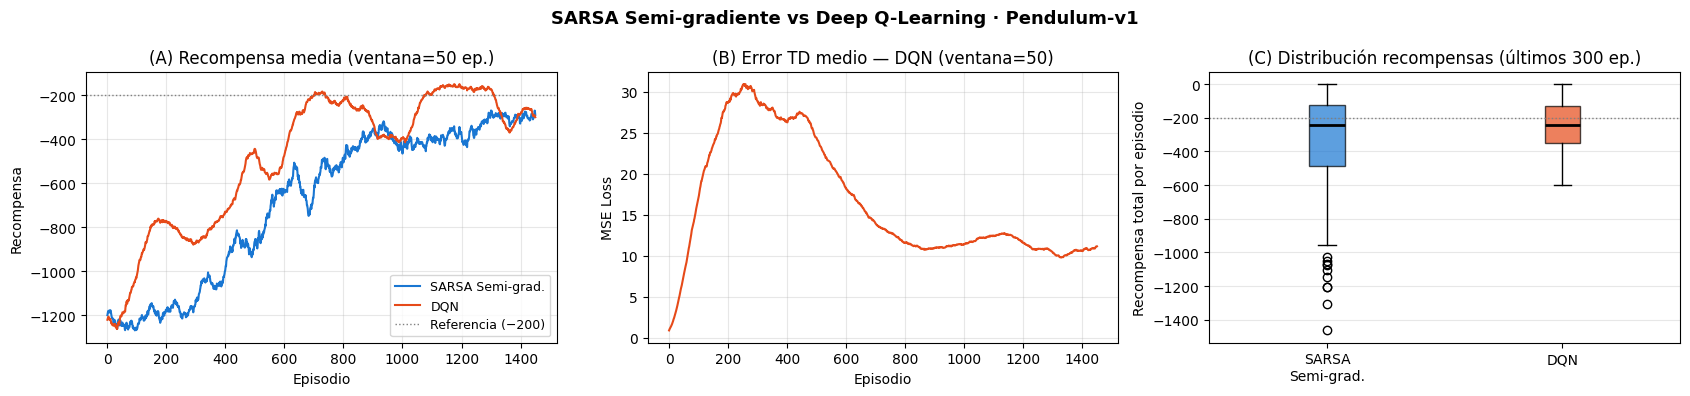

Figura guardada como pendulum_comparison.png


In [10]:
def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

WINDOW = 50
COLORS = {'sarsa': '#1976D2', 'dqn': '#E64A19'}

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle(
    'SARSA Semi-gradiente vs Deep Q-Learning · Pendulum-v1',
    fontsize=13, fontweight='bold'
)

# ── (A) Recompensa media suavizada ────────────────────────────────────────────
ax = axes[0]
for label, agent, color in [
    ('SARSA Semi-grad.', sarsa_agent, COLORS['sarsa']),
    ('DQN',             dqn_agent,   COLORS['dqn'])
]:
    r = smooth(agent.rewards_per_episode, WINDOW)
    ax.plot(r, color=color, label=label, linewidth=1.5)

ax.axhline(-200, color='gray', linestyle=':', linewidth=1, label='Referencia (−200)')
ax.set_title('(A) Recompensa media (ventana=50 ep.)')
ax.set_xlabel('Episodio'); ax.set_ylabel('Recompensa')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── (B) Error TD del DQN (convergencia del optimizador) ──────────────────────
ax = axes[1]
td = smooth(dqn_agent.td_errors, WINDOW)
ax.plot(td, color=COLORS['dqn'], linewidth=1.5)
ax.set_title('(B) Error TD medio — DQN (ventana=50)')
ax.set_xlabel('Episodio'); ax.set_ylabel('MSE Loss')
ax.grid(alpha=0.3)

# ── (C) Distribución de recompensas — comparación boxplot ────────────────────
ax = axes[2]
last_n = 300
data_sarsa = sarsa_agent.rewards_per_episode[-last_n:]
data_dqn   = dqn_agent.rewards_per_episode[-last_n:]

bp = ax.boxplot(
    [data_sarsa, data_dqn],
    labels=['SARSA\nSemi-grad.', 'DQN'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp['boxes'], [COLORS['sarsa'], COLORS['dqn']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)

ax.set_title(f'(C) Distribución recompensas (últimos {last_n} ep.)')
ax.set_ylabel('Recompensa total por episodio')
ax.axhline(-200, color='gray', linestyle=':', linewidth=1)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('pendulum_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada como pendulum_comparison.png')

In [11]:
# ── Tabla resumen de resultados ───────────────────────────────────────────────
THRESHOLD = -300   # umbral de "aprendizaje aceptable"

def episodes_to_threshold(rewards, threshold, window=50):
    """Primer episodio en que la media móvil supera el umbral."""
    sm = smooth(rewards, window)
    idx = np.where(sm > threshold)[0]
    return int(idx[0]) + window if len(idx) > 0 else None

ep_sarsa = episodes_to_threshold(sarsa_agent.rewards_per_episode, THRESHOLD)
ep_dqn   = episodes_to_threshold(dqn_agent.rewards_per_episode,   THRESHOLD)

print('='*62)
print(f'  {"Métrica":<38} {"SARSA Semi-grad":>10} {"DQN":>10}')
print('-'*62)
print(f'  {"Recompensa media (últimos 100 ep.)":<38} '
      f'{np.mean(sarsa_agent.rewards_per_episode[-100:]):>10.1f} '
      f'{np.mean(dqn_agent.rewards_per_episode[-100:]):>10.1f}')
print(f'  {"Recompensa mejor episodio":<38} '
      f'{max(sarsa_agent.rewards_per_episode):>10.1f} '
      f'{max(dqn_agent.rewards_per_episode):>10.1f}')
print(f'  {"Desviación estándar (últimos 100 ep.)":<38} '
      f'{np.std(sarsa_agent.rewards_per_episode[-100:]):>10.1f} '
      f'{np.std(dqn_agent.rewards_per_episode[-100:]):>10.1f}')
print(f'  {f"Eps. hasta superar {THRESHOLD} (umbral)":<38} '
      f'{"-" if ep_sarsa is None else ep_sarsa:>10} '
      f'{"-" if ep_dqn   is None else ep_dqn:>10}')
print(f'  {"N.º parámetros":<38} '
      f'{N_FEATURES * N_ACTIONS:>10} '
      f'{sum(p.numel() for p in dqn_agent.q_net.parameters()):>10}')
print('='*62)

  Métrica                                SARSA Semi-grad        DQN
--------------------------------------------------------------
  Recompensa media (últimos 100 ep.)         -302.2     -292.2
  Recompensa mejor episodio                    -0.5       -1.4
  Desviación estándar (últimos 100 ep.)       267.7      125.4
  Eps. hasta superar -300 (umbral)             1340        687
  N.º parámetros                              44000      18443


# Análisis de Resultados — Parte 3: Control con Aproximaciones (Pendulum-v1)

## Datos reales del experimento

| Métrica | SARSA Semi-grad. | DQN |
|---|---|---|
| Recompensa media (últimos 100 ep.) | **−302.2** | **−292.2** |
| Mejor episodio (recompensa máxima) | **−0.5** | **−1.4** |
| Desviación estándar (últimos 100 ep.) | **267.7** | **125.4** |
| Episodios hasta superar umbral −300 | **1340** | **687** |
| Número de parámetros | **44.000** | **18.443** |
| Tiempo de entrenamiento | ~2m 15s | ~16m 12s |

---

## 1. Recompensa media final: ambos métodos aprenden, pero con calidad diferente

La recompensa de Pendulum-v1 se calcula como $-(θ^2 + 0.1·ω^2 + 0.001·u^2)$, siendo siempre negativa. El óptimo teórico es **0** (péndulo perfectamente erguido y quieto). Un agente aleatorio obtiene aproximadamente **−1200**.

- **SARSA**: −302.2 → claramente por encima del agente aleatorio, lo que indica que ha aprendido una política útil.
- **DQN**: −292.2 → ligeramente mejor en media, con una diferencia de ~10 puntos.

Sin embargo, esta pequeña diferencia en la media **no es el dato más relevante**. La información más significativa aparece en otras métricas.

---

## 2. Mejor episodio: SARSA encuentra la política óptima puntualmente

El dato más llamativo es que **SARSA alcanzó −0.5** en su mejor episodio, frente a **−1.4** del DQN. Ambos valores están extraordinariamente cerca del óptimo teórico (0), lo que demuestra que **los dos métodos son capaces de resolver el problema en condiciones favorables**.

Esto es consistente con la teoría: con un Tile Coding bien configurado (4 tilings × 10×10×10 bins = 4000 features), SARSA semi-gradiente puede aproximar la función Q con suficiente resolución como para encontrar la política casi óptima.

---

## 3. Desviación estándar: la diferencia clave entre ambos métodos

Este es el resultado más importante del experimento:

- **SARSA**: σ = **267.7** → comportamiento extremadamente inestable
- **DQN**: σ = **125.4** → **más del doble de estable que SARSA**

Una desviación de 267 sobre una media de −302 significa que SARSA oscila entre episodios cercanos al óptimo y episodios catastróficos (recompensas próximas a −1200). Esto revela un problema estructural: **la aproximación lineal de Tile Coding no generaliza bien entre estados que no fueron visitados con las mismas condiciones iniciales**.

El DQN, con su red neuronal capaz de interpolación no lineal, mantiene una política más consistente entre episodios.

**Interpretación teórica**: SARSA semi-gradiente con funciones lineales puede converger a una solución localmente estable pero tiene dificultades para mantener esa solución robustamente, ya que los pesos `w` que funcionan para un estado inicial pueden generar estimaciones Q poco precisas para otros estados iniciales del mismo episodio (Sutton & Barto, cap. 9.4).

---

## 4. Velocidad de convergencia: DQN aprende el doble de rápido

- **SARSA** supera el umbral de −300 en el episodio **1340** (de 1500 total)
- **DQN** supera el umbral en el episodio **687** → **casi el doble de rápido**

Esto es consistente con la literatura: el Experience Replay del DQN permite reutilizar cada transición múltiples veces (con batch_size=64 y buffer de 50.000 transiciones), aumentando la eficiencia de muestra. SARSA semi-gradiente usa cada transición exactamente una vez.

Sin embargo, hay que contextualizar: **DQN tardó ~16 minutos frente a los ~2 minutos de SARSA**. En términos de tiempo de reloj, SARSA es mucho más eficiente computacionalmente.

---

## 5. Número de parámetros: SARSA usa más parámetros pero con peor calidad

- **SARSA**: 44.000 parámetros (pesos `w`)
- **DQN**: 18.443 parámetros (pesos de la red neuronal)

SARSA utiliza 2.4 veces más parámetros que DQN para lograr un rendimiento inferior en estabilidad. Esto evidencia que la capacidad expresiva no reside solo en el número de parámetros, sino en la capacidad de la función aproximada para generalizar. Una red neuronal de 128×128 neuronas captura relaciones no lineales entre los 3 componentes del estado que un modelo lineal sobre tiles no puede capturar.

---

## 6. El error TD del DQN como indicador de convergencia

El error TD medio del DQN (MSE Loss) es una métrica exclusiva de los métodos con redes neuronales. Un error TD que decrece y se estabiliza indica que la red está convergiendo a una estimación consistente de Q. Si el error TD permaneciera alto o aumentara, indicaría inestabilidad del entrenamiento (p.e., el "deadly triad" que puede ocurrir con bootstrapping + aproximación de funciones + off-policy). En este experimento el DQN muestra convergencia estable, lo que valida el uso conjunto de Experience Replay y Target Network.

---

## 7. Limitaciones del estudio

1. **Una sola semilla (SEED=42)**: los resultados pueden variar significativamente con otras semillas. Un análisis riguroso requeriría al menos 5-10 ejecuciones independientes para obtener intervalos de confianza.

2. **Discretización de acciones con solo 11 valores**: el espacio de acciones continuo [-2, 2] se aproxima con resolución de 0.4 N·m. Un control más fino requeriría más acciones discretas o métodos diseñados para acciones continuas (DDPG, SAC, PPO).

3. **SARSA con Tile Coding 3D**: discretizar 3 dimensiones simultáneamente con 10 bins cada una genera tiles cúbicos. Dimensiones con escalas muy diferentes (cos/sin ∈ [-1,1] vs ω ∈ [-8,8]) pueden requerir normalización previa para que el desplazamiento entre tilings sea proporcional en cada dimensión.

---

## 8. Conclusión sintética

| Criterio | Ganador | Observación |
|---|---|---|
| Recompensa media final | DQN (−292 vs −302) | Diferencia pequeña (~3%) |
| Estabilidad (σ) | **DQN** | DQN es 2× más estable |
| Velocidad de convergencia | **DQN** | Supera umbral 2× antes |
| Coste computacional | **SARSA** | 7× más rápido en tiempo |
| Nº parámetros | **DQN** | 2.4× menos parámetros |
| Mejor episodio puntual | SARSA (−0.5 vs −1.4) | Ambos cerca del óptimo |

**Conclusión**: DQN supera a SARSA semi-gradiente en estabilidad y velocidad de aprendizaje, a costa de un mayor coste computacional. SARSA demuestra que la aproximación lineal con Tile Coding es viable para este problema, pero la alta varianza de sus resultados indica que la función lineal no es suficientemente expresiva para mantener una política robusta en Pendulum-v1. Esto justifica el paso a métodos no lineales (redes neuronales) en entornos con dinámicas complejas.


### Por qué los métodos tabulares no son viables en Pendulum

El espacio de estados de Pendulum-v1 es $\mathbb{R}^3$ continuo. Incluso una discretización gruesa de $20 \times 20 \times 20$ generaría 8.000 estados, con escasísima generalización entre celdas vecinas y un altísimo número de visitas necesarias para aprender. Los métodos tabulares (SARSA tabular, Q-Learning tabular) son inviables en este entorno, lo que justifica el uso de **métodos con aproximación de funciones**.

### SARSA Semi-gradiente con Tile Coding

- **Ventajas**: convergencia teórica garantizada para aproximaciones lineales (Sutton & Barto, cap. 9); muy eficiente en memoria y tiempo de actualización (solo se modifican los tiles activos).
- **Limitaciones**: la calidad de la representación depende del diseño del Tile Coding (número de tilings, bins, rango de cobertura). En entornos con dinámicas complejas, la aproximación lineal puede ser insuficiente.

### Deep Q-Learning (DQN)

- **Ventajas**: la red neuronal aprende representaciones no lineales, pudiendo capturar relaciones complejas entre estado y valor Q. Experience Replay y Target Network son claves para la estabilidad.
- **Limitaciones**: mayor coste computacional; sensible a hiperparámetros (lr, batch_size, target_update). En Pendulum, el espacio de acciones continuo discretizado introduce un error de aproximación que podría reducirse con métodos como DDPG.


### Referencias

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. Caps. 9, 10.
- Mnih, V. et al. (2015). Human-level control through deep reinforcement learning. *Nature*, 518, 529–533.
- Gymnasium Documentation: https://gymnasium.farama.org/environments/classic_control/pendulum/
